# Laboratorul 2 — Autoencoder clasic și Variațional pe MNIST

## Obiectiv

Acest notebook implementează, antrenează și compară două modele encoder–decoder pe setul MNIST:

1. un **autoencoder clasic (AE)** pentru comprimare și reconstrucție;
2. un **Variational Autoencoder (VAE)** pentru reconstrucție și generare de imagini.

Ambele modele sunt rețele fully connected cu un spațiu latent bidimensional. Pentru o rulare de verificare rapidă se poate activa `FAST_RUN = True`; pentru rezultatele raportului se rulează cu `FAST_RUN = False`.

## 1. Configurarea mediului de lucru

Această secțiune verifică versiunea Python, afișează directorul curent și creează directoarele utilizate pentru date, modele și grafice. Toate căile sunt relative la directorul notebook-ului.

In [1]:
from pathlib import Path
import platform
import sys

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
FIGURES_DIR = PROJECT_ROOT / "figures"

for directory in (DATA_DIR, MODELS_DIR, FIGURES_DIR):
    directory.mkdir(parents=True, exist_ok=True)

print(f"Python: {sys.version.split()[0]}")
print(f"Platformă: {platform.platform()}")
print(f"Director curent: {PROJECT_ROOT}")
print("Directoare pregătite:", ", ".join(str(path.name) for path in (DATA_DIR, MODELS_DIR, FIGURES_DIR)))

Python: 3.14.2
Platformă: Windows-11-10.0.26200-SP0
Director curent: d:\Gorincioi_Igor\Python\Master\Anul 2\Sem 1\Inteligența Artificială Generativă\Lab 2
Directoare pregătite: data, models, figures


## 2. Importul dependențelor

`torchvision` furnizează setul MNIST, iar PyTorch va fi utilizat pentru definirea și antrenarea modelelor. Matplotlib este folosit pentru toate graficele statice ale laboratorului.

In [57]:
import copy
import random
import time
from dataclasses import dataclass
from typing import Literal

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import Tensor, nn
from torch.nn import functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader, Dataset, Subset, random_split
from torchvision import datasets, transforms
from tqdm.auto import tqdm

print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponibil: {torch.cuda.is_available()}")

PyTorch: 2.14.0+cpu
CUDA disponibil: False


## 3. Definirea configurației experimentului

`FAST_RUN` permite verificarea rapidă a întregului flux. Pentru rezultatele finale ale laboratorului, setați `FAST_RUN = False`. Dimensiunea latentă este 2 pentru a permite vizualizarea directă a spațiului latent și generarea pe o grilă 2D.

In [58]:
@dataclass(frozen=True)
class Config:
    seed: int = 42
    batch_size: int = 256
    learning_rate: float = 1e-3
    epochs: int = 60
    latent_dim: int = 2
    hidden_dims: tuple[int, int] = (512, 256, 128, 64)
    beta: float = 1.0
    validation_size: int = 10_000
    num_workers: int = 0
    early_stopping_patience: int = 16
    early_stopping_min_delta: float = 0.05
    fast_run: bool = False
    fast_train_size: int = 5_000
    fast_validation_size: int = 1_000
    fast_test_size: int = 1_000


CONFIG = Config()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def seed_everything(seed: int) -> None:
    """Fixează sursele principale de aleatoritate pentru experimente repetabile."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(CONFIG.seed)
print(f"Dispozitiv selectat: {DEVICE}")
print(CONFIG)

Dispozitiv selectat: cpu
Config(seed=42, batch_size=256, learning_rate=0.001, epochs=60, latent_dim=2, hidden_dims=(512, 256, 128, 64), beta=1.0, validation_size=10000, num_workers=0, early_stopping_patience=16, early_stopping_min_delta=0.05, fast_run=False, fast_train_size=5000, fast_validation_size=1000, fast_test_size=1000)


## 4. Implementarea componentelor de bază

### 4.1. Încărcarea și inspectarea MNIST

Imaginile sunt normalizate în intervalul $[0,1]$. Setul de antrenare este împărțit reproductibil în train și validation; setul test rămâne rezervat evaluării finale.

Train / validation / test: 50000 / 10000 / 10000
Forma unui batch: (256, 1, 28, 28)
Interval pixeli: [0.0, 1.0]


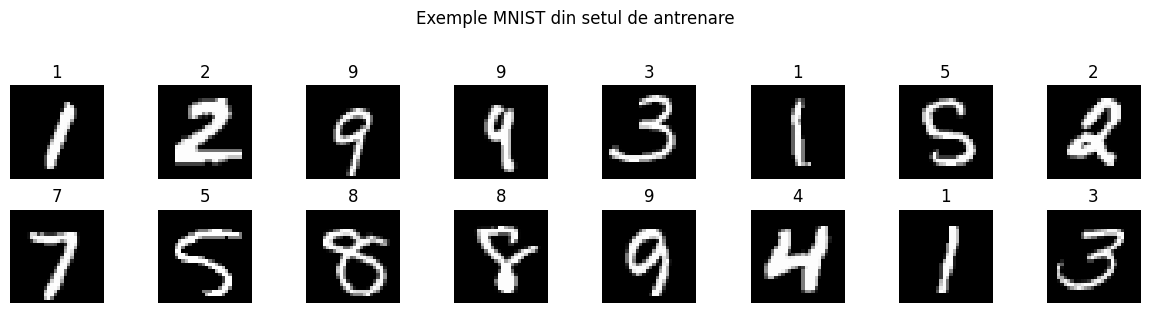

In [71]:
def build_dataloaders(config: Config) -> tuple[DataLoader, DataLoader, DataLoader]:
    """Descarcă MNIST și întoarce dataloaderele train, validation și test."""
    transform = transforms.ToTensor()
    full_train = datasets.MNIST(DATA_DIR, train=True, download=True, transform=transform)
    test_dataset: Dataset = datasets.MNIST(DATA_DIR, train=False, download=True, transform=transform)

    train_size = len(full_train) - config.validation_size
    generator = torch.Generator().manual_seed(config.seed)
    train_dataset, validation_dataset = random_split(
        full_train,
        [train_size, config.validation_size],
        generator=generator,
    )

    if config.fast_run:
        train_dataset = Subset(train_dataset, range(min(config.fast_train_size, len(train_dataset))))
        validation_dataset = Subset(
            validation_dataset,
            range(min(config.fast_validation_size, len(validation_dataset))),
        )
        test_dataset = Subset(test_dataset, range(min(config.fast_test_size, len(test_dataset))))

    loader_options = {
        "batch_size": config.batch_size,
        "num_workers": config.num_workers,
        "pin_memory": DEVICE.type == "cuda",
    }
    train_loader = DataLoader(train_dataset, shuffle=True, **loader_options)
    validation_loader = DataLoader(validation_dataset, shuffle=False, **loader_options)
    test_loader = DataLoader(test_dataset, shuffle=False, **loader_options)
    return train_loader, validation_loader, test_loader


train_loader, validation_loader, test_loader = build_dataloaders(CONFIG)
images, labels = next(iter(train_loader))

print(f"Train / validation / test: {len(train_loader.dataset)} / {len(validation_loader.dataset)} / {len(test_loader.dataset)}")
print(f"Forma unui batch: {tuple(images.shape)}")
print(f"Interval pixeli: [{images.min().item():.1f}, {images.max().item():.1f}]")

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for axis, image, label in zip(axes.ravel(), images[:16], labels[:16]):
    axis.imshow(image.squeeze(0), cmap="gray", vmin=0, vmax=1)
    axis.set_title(str(label.item()))
    axis.axis("off")
fig.suptitle("Exemple MNIST din setul de antrenare", y=1.03)
plt.tight_layout()
plt.savefig('figures/exemple de date.png')
plt.show()

### 4.2. Modelele AE și VAE

Autoencoderul clasic învață o reprezentare deterministă $z$. VAE produce parametrii distribuției latente $q_\phi(z|x)=\mathcal N(\mu, \sigma^2I)$ și eșantionează prin reparameterization trick:

$$z = \mu + \exp(0.5\cdot\log\sigma^2)\odot\epsilon,\quad \epsilon\sim\mathcal N(0,I).$$

In [60]:
class Autoencoder(nn.Module):
    """Autoencoder fully connected pentru imagini MNIST de 28×28 pixeli."""

    def __init__(self, hidden_dims: tuple[int, ...], latent_dim: int) -> None:
        super().__init__()
        if not hidden_dims:
            raise ValueError("hidden_dims trebuie să conțină cel puțin un strat ascuns.")

        encoder_layers: list[nn.Module] = [nn.Flatten()]
        input_dim = 28 * 28
        for hidden_dim in hidden_dims:
            encoder_layers.extend((nn.Linear(input_dim, hidden_dim), nn.ReLU()))
            input_dim = hidden_dim
        encoder_layers.append(nn.Linear(input_dim, latent_dim))
        self.encoder = nn.Sequential(*encoder_layers)

        decoder_layers: list[nn.Module] = []
        input_dim = latent_dim
        for hidden_dim in reversed(hidden_dims):
            decoder_layers.extend((nn.Linear(input_dim, hidden_dim), nn.ReLU()))
            input_dim = hidden_dim
        decoder_layers.extend((nn.Linear(input_dim, 28 * 28), nn.Sigmoid()))
        self.decoder = nn.Sequential(*decoder_layers)

    def encode(self, x: Tensor) -> Tensor:
        return self.encoder(x)

    def decode(self, z: Tensor) -> Tensor:
        return self.decoder(z).view(-1, 1, 28, 28)

    def forward(self, x: Tensor) -> tuple[Tensor, Tensor]:
        z = self.encode(x)
        return self.decode(z), z


class VariationalAutoencoder(nn.Module):
    """VAE fully connected cu posterior gaussian diagonal și decoder Bernoulli."""

    def __init__(self, hidden_dims: tuple[int, ...], latent_dim: int) -> None:
        super().__init__()
        if not hidden_dims:
            raise ValueError("hidden_dims trebuie să conțină cel puțin un strat ascuns.")

        encoder_layers: list[nn.Module] = [nn.Flatten()]
        input_dim = 28 * 28
        for hidden_dim in hidden_dims:
            encoder_layers.extend((nn.Linear(input_dim, hidden_dim), nn.ReLU()))
            input_dim = hidden_dim
        self.encoder = nn.Sequential(*encoder_layers)
        self.mu_layer = nn.Linear(input_dim, latent_dim)
        self.log_var_layer = nn.Linear(input_dim, latent_dim)

        decoder_layers: list[nn.Module] = []
        input_dim = latent_dim
        for hidden_dim in reversed(hidden_dims):
            decoder_layers.extend((nn.Linear(input_dim, hidden_dim), nn.ReLU()))
            input_dim = hidden_dim
        decoder_layers.extend((nn.Linear(input_dim, 28 * 28), nn.Sigmoid()))
        self.decoder = nn.Sequential(*decoder_layers)

    def encode(self, x: Tensor) -> tuple[Tensor, Tensor]:
        hidden = self.encoder(x)
        return self.mu_layer(hidden), self.log_var_layer(hidden)

    @staticmethod
    def reparameterize(mu: Tensor, log_var: Tensor) -> Tensor:
        std = torch.exp(0.5 * log_var)
        return mu + torch.randn_like(std) * std

    def decode(self, z: Tensor) -> Tensor:
        return self.decoder(z).view(-1, 1, 28, 28)

    def forward(self, x: Tensor, *, sample: bool = True) -> tuple[Tensor, Tensor, Tensor, Tensor]:
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var) if sample else mu
        return self.decode(z), mu, log_var, z


def count_parameters(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


ae = Autoencoder(CONFIG.hidden_dims, CONFIG.latent_dim).to(DEVICE)
vae = VariationalAutoencoder(CONFIG.hidden_dims, CONFIG.latent_dim).to(DEVICE)
print(f"Parametri AE:  {count_parameters(ae):,}")
print(f"Parametri VAE: {count_parameters(vae):,}")

Parametri AE:  1,149,842
Parametri VAE: 1,149,972


### 4.3. Funcții reutilizabile de antrenare și evaluare

Pentru AE, funcția obiectiv este BCE medie pe pixel. Pentru VAE:

$$\mathcal L_{VAE}=\mathcal L_{rec}+\beta\mathcal L_{KL},$$

unde $\mathcal L_{KL}$ regularizează posteriorul aproximat către priorul $\mathcal N(0,I)$. Toate valorile raportate sunt medii per imagine.

In [ ]:
ModelKind = Literal["ae", "vae"]


def vae_loss(reconstruction: Tensor, target: Tensor, mu: Tensor, log_var: Tensor, beta: float) -> tuple[Tensor, Tensor, Tensor]:
    """Calculează pierderea VAE: BCE per imagine + beta × KL per imagine."""
    reconstruction_loss = F.binary_cross_entropy(reconstruction, target, reduction="sum") / target.size(0)
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / target.size(0)
    return reconstruction_loss + beta * kl_loss, reconstruction_loss, kl_loss


def run_epoch(
    model: nn.Module,
    loader: DataLoader,
    model_kind: ModelKind,
    *,
    optimizer: Adam | None = None,
    beta: float = 1.0,
) -> dict[str, float]:
    """Rulează o epocă de train (cu optimizer) sau de evaluare (fără optimizer)."""
    training = optimizer is not None
    model.train(training)
    totals = {"total": 0.0, "reconstruction": 0.0, "kl": 0.0, "samples": 0}

    context = torch.enable_grad() if training else torch.no_grad()
    with context:
        for batch_images, _ in loader:
            batch_images = batch_images.to(DEVICE, non_blocking=True)
            if training:
                optimizer.zero_grad(set_to_none=True)

            if model_kind == "ae":
                reconstruction, _ = model(batch_images)
                reconstruction_loss = F.binary_cross_entropy(reconstruction, batch_images, reduction="sum") / batch_images.size(0)
                total_loss, kl_loss = reconstruction_loss, torch.zeros((), device=DEVICE)
            else:
                reconstruction, mu, log_var, _ = model(batch_images, sample=training)
                total_loss, reconstruction_loss, kl_loss = vae_loss(
                    reconstruction,
                    batch_images,
                    mu,
                    log_var,
                    beta,
                )

            if training:
                total_loss.backward()
                optimizer.step()

            size = batch_images.size(0)
            totals["total"] += total_loss.item() * size
            totals["reconstruction"] += reconstruction_loss.item() * size
            totals["kl"] += kl_loss.item() * size
            totals["samples"] += size

    return {name: totals[name] / totals["samples"] for name in ("total", "reconstruction", "kl")}


def train_model(model: nn.Module, model_kind: ModelKind, config: Config) -> tuple[dict[str, list[float]], float]:
    """Antrenează modelul cu early stopping pe validation total loss și restaurează cea mai bună stare."""
    optimizer = Adam(model.parameters(), lr=config.learning_rate)
    history = {f"{split}_{metric}": [] for split in ("train", "validation") for metric in ("total", "reconstruction", "kl")}
    best_state, best_validation_loss = None, float("inf")
    epochs_without_improvement = 0
    start_time = time.perf_counter()

    for epoch in tqdm(range(1, config.epochs + 1), desc=f"Antrenare {model_kind.upper()}"):
        train_metrics = run_epoch(model, train_loader, model_kind, optimizer=optimizer, beta=config.beta)
        validation_metrics = run_epoch(model, validation_loader, model_kind, beta=config.beta)

        for split, metrics in (("train", train_metrics), ("validation", validation_metrics)):
            for metric, value in metrics.items():
                history[f"{split}_{metric}"].append(value)

        improved = validation_metrics["total"] < best_validation_loss - config.early_stopping_min_delta
        if improved:
            best_validation_loss = validation_metrics["total"]
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        print(
            f"Epoca {epoch:02d}/{config.epochs} | "
            f"train={train_metrics['total']:.3f} | val={validation_metrics['total']:.3f} | "
            f"train_rec={train_metrics['reconstruction']:.3f} | val_rec={validation_metrics['reconstruction']:.3f} | "
            f"train_kl={train_metrics['kl']:.3f} | val_kl={validation_metrics['kl']:.3f} | "
            f"fără îmbunătățire={epochs_without_improvement}/{config.early_stopping_patience}"
        )

        if epochs_without_improvement >= config.early_stopping_patience:
            print(
                f"Early stopping la epoca {epoch}: validation total loss nu s-a îmbunătățit cu cel puțin "
                f"{config.early_stopping_min_delta:.3f} timp de {config.early_stopping_patience} epoci."
            )
            break

    if best_state is None:
        raise RuntimeError("Nu a fost salvată nicio stare a modelului.")
    model.load_state_dict(best_state)
    print(f"A fost restaurată cea mai bună stare: validation total loss = {best_validation_loss:.3f}.")
    return history, time.perf_counter() - start_time


def evaluate_model(model: nn.Module, model_kind: ModelKind, config: Config) -> dict[str, float]:
    return run_epoch(model, test_loader, model_kind, beta=config.beta)


def plot_history(history: dict[str, list[float]], model_kind: ModelKind) -> None:
    epochs = np.arange(1, len(history["train_total"]) + 1)
    figure, axes = plt.subplots(1, 2 if model_kind == "vae" else 1, figsize=(12 if model_kind == "vae" else 6, 4))
    axes = np.atleast_1d(axes)

    axes[0].plot(epochs, history["train_total"], label="train")
    axes[0].plot(epochs, history["validation_total"], label="validation")
    axes[0].set(title=f"{model_kind.upper()} — loss total", xlabel="Epocă", ylabel="BCE / imagine")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    if model_kind == "vae":
        axes[1].plot(epochs, history["train_reconstruction"], label="train reconstruction")
        axes[1].plot(epochs, history["validation_reconstruction"], label="validation reconstruction")
        axes[1].plot(epochs, history["train_kl"], "--", label="train KL")
        axes[1].plot(epochs, history["validation_kl"], "--", label="validation KL")
        axes[1].set(title="VAE — componentele pierderii", xlabel="Epocă", ylabel="loss / imagine")
        axes[1].legend()
        axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'figures/plot_history_{model_kind}.png')
    plt.show()

In [62]:
# Verificare structurală înainte de antrenare: forme corecte și pierderi finite.
with torch.no_grad():
    validation_batch = images[:8].to(DEVICE)
    ae_output, ae_latent = ae(validation_batch)
    vae_output, vae_mu, vae_log_var, vae_latent = vae(validation_batch)
    _, vae_reconstruction_loss, vae_kl_loss = vae_loss(
        vae_output,
        validation_batch,
        vae_mu,
        vae_log_var,
        CONFIG.beta,
    )

assert ae_output.shape == validation_batch.shape == vae_output.shape
assert ae_latent.shape == vae_mu.shape == vae_log_var.shape == vae_latent.shape == (8, CONFIG.latent_dim)
assert torch.isfinite(ae_output).all() and torch.isfinite(vae_output).all()
assert torch.isfinite(vae_reconstruction_loss) and torch.isfinite(vae_kl_loss)
print("✓ AE și VAE produc forme compatibile, coduri latente 2D și pierderi finite.")

✓ AE și VAE produc forme compatibile, coduri latente 2D și pierderi finite.


## 5. Rularea scenariului principal

### 5.1. Antrenarea autoencoderului clasic

Se reconstruiește imaginea de intrare și se minimizează binary cross-entropy. Rulați această celulă înainte de secțiunile de comparație.

Antrenare AE:   2%|▏         | 1/60 [00:06<06:16,  6.37s/it]

Epoca 01/60 | train=212.143 | val=180.639 | train_rec=212.143 | val_rec=180.639 | train_kl=0.000 | val_kl=0.000 | fără îmbunătățire=0/16


Antrenare AE:   3%|▎         | 2/60 [00:17<09:04,  9.38s/it]

Epoca 02/60 | train=168.082 | val=158.139 | train_rec=168.082 | val_rec=158.139 | train_kl=0.000 | val_kl=0.000 | fără îmbunătățire=0/16


Antrenare AE:   5%|▌         | 3/60 [00:34<11:54, 12.53s/it]

...

Epoca 51/60 | train=131.946 | val=132.020 | train_rec=131.946 | val_rec=132.020 | train_kl=0.000 | val_kl=0.000 | fără îmbunătățire=14/16


Antrenare AE:  87%|████████▋ | 52/60 [18:32<03:05, 23.14s/it]

Epoca 52/60 | train=131.223 | val=131.799 | train_rec=131.223 | val_rec=131.799 | train_kl=0.000 | val_kl=0.000 | fără îmbunătățire=15/16


Antrenare AE:  87%|████████▋ | 52/60 [18:55<02:54, 21.84s/it]

Epoca 53/60 | train=131.056 | val=131.571 | train_rec=131.056 | val_rec=131.571 | train_kl=0.000 | val_kl=0.000 | fără îmbunătățire=16/16
Early stopping la epoca 53: validation total loss nu s-a îmbunătățit cu cel puțin 0.050 timp de 16 epoci.
A fost restaurată cea mai bună stare: validation total loss = 129.363.


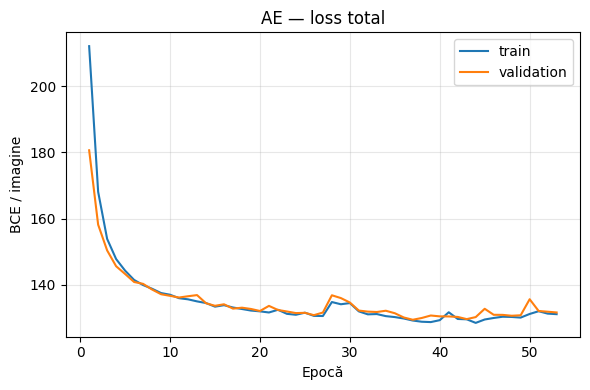

AE test reconstruction loss: 129.567
AE timp de antrenare: 1135.7 secunde


In [ ]:
seed_everything(CONFIG.seed)
ae = Autoencoder(CONFIG.hidden_dims, CONFIG.latent_dim).to(DEVICE)
ae_history, ae_train_seconds = train_model(ae, "ae", CONFIG)
ae_test_metrics = evaluate_model(ae, "ae", CONFIG)
plot_history(ae_history, "ae")

print(f"AE test reconstruction loss: {ae_test_metrics['reconstruction']:.3f}")
print(f"AE timp de antrenare: {ae_train_seconds:.1f} secunde")
torch.save(ae.state_dict(), MODELS_DIR / "ae_best.pt")

### 5.2. Antrenarea Variational Autoencoder

În plus față de reconstruction loss, VAE minimizează divergența KL dintre distribuția latentă învățată și priorul gaussian standard. Această regularizare permite generarea de imagini noi prin eșantionare din $\mathcal N(0,I)$.

Antrenare VAE:   2%|▏         | 1/60 [00:04<04:25,  4.50s/it]

Epoca 01/60 | train=215.149 | val=187.438 | train_rec=213.790 | val_rec=185.130 | train_kl=1.359 | val_kl=2.308 | fără îmbunătățire=0/16


Antrenare VAE:   3%|▎         | 2/60 [00:12<06:28,  6.70s/it]

Epoca 02/60 | train=185.558 | val=181.965 | train_rec=183.116 | val_rec=179.494 | train_kl=2.441 | val_kl=2.471 | fără îmbunătățire=0/16


Antrenare VAE:   5%|▌         | 3/60 [00:27<10:02, 10.57s/it]

...

Epoca 58/60 | train=136.570 | val=135.887 | train_rec=129.486 | val_rec=128.851 | train_kl=7.084 | val_kl=7.035 | fără îmbunătățire=6/16


Antrenare VAE:  98%|█████████▊| 59/60 [19:14<00:18, 18.06s/it]

Epoca 59/60 | train=136.375 | val=136.285 | train_rec=129.292 | val_rec=129.280 | train_kl=7.083 | val_kl=7.004 | fără îmbunătățire=7/16


Antrenare VAE: 100%|██████████| 60/60 [19:32<00:00, 19.54s/it]

Epoca 60/60 | train=136.135 | val=136.218 | train_rec=129.052 | val_rec=129.164 | train_kl=7.083 | val_kl=7.054 | fără îmbunătățire=8/16
A fost restaurată cea mai bună stare: validation total loss = 135.925.


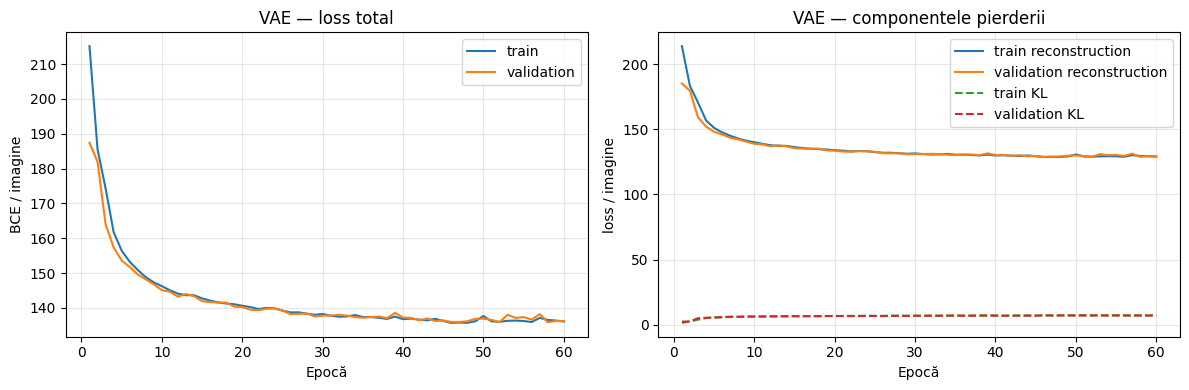

VAE test total loss: 135.862
VAE test reconstruction loss: 128.827
VAE test KL loss: 7.035
VAE timp de antrenare: 1172.2 secunde


In [64]:
seed_everything(CONFIG.seed)
vae = VariationalAutoencoder(CONFIG.hidden_dims, CONFIG.latent_dim).to(DEVICE)
vae_history, vae_train_seconds = train_model(vae, "vae", CONFIG)
vae_test_metrics = evaluate_model(vae, "vae", CONFIG)
plot_history(vae_history, "vae")

print(f"VAE test total loss: {vae_test_metrics['total']:.3f}")
print(f"VAE test reconstruction loss: {vae_test_metrics['reconstruction']:.3f}")
print(f"VAE test KL loss: {vae_test_metrics['kl']:.3f}")
print(f"VAE timp de antrenare: {vae_train_seconds:.1f} secunde")
torch.save(vae.state_dict(), MODELS_DIR / "vae_best.pt")

## 6. Verificarea funcționalității de bază și comparația rezultatelor

### 6.1. Metrici finale și reconstrucții

**Notă:** loss-ul total VAE include termenul KL, deci nu este comparabil direct cu loss-ul AE. Pentru fidelitatea reconstrucției se compară `reconstruction loss`.

Model        Parametri    Timp (s)     Rec. loss     KL loss
AE           1,149,842      1135.7       129.567       0.000
VAE          1,149,972      1172.2       128.827       7.035


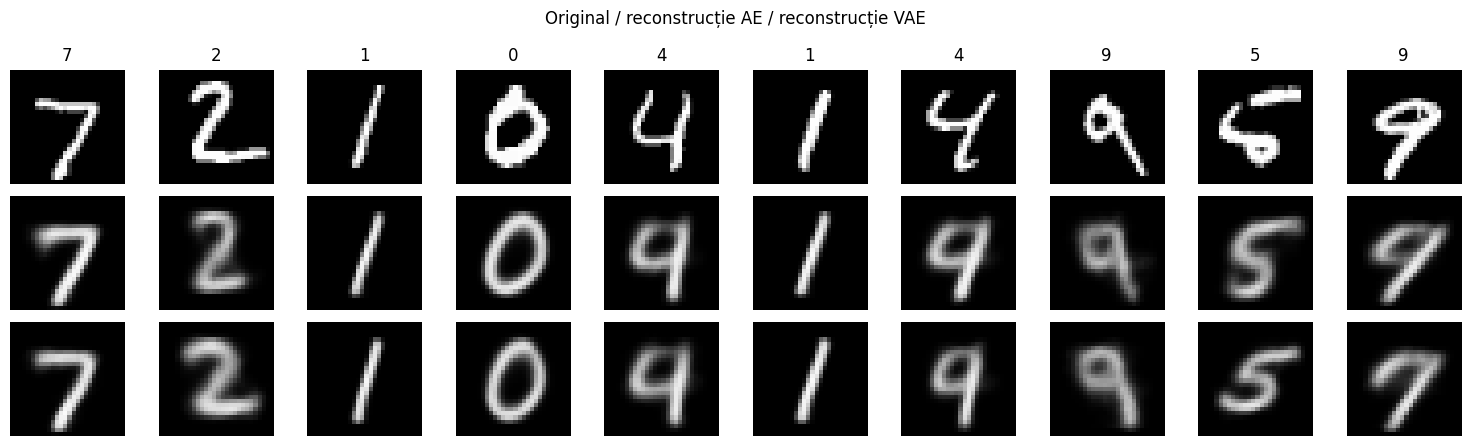

✓ Reconstrucțiile au formă corectă, valori finite și intervalul [0, 1].


In [70]:
comparison = {
    "AE": {
        "parametri": count_parameters(ae),
        "timp (s)": ae_train_seconds,
        "test reconstruction loss": ae_test_metrics["reconstruction"],
        "test KL loss": 0.0,
    },
    "VAE": {
        "parametri": count_parameters(vae),
        "timp (s)": vae_train_seconds,
        "test reconstruction loss": vae_test_metrics["reconstruction"],
        "test KL loss": vae_test_metrics["kl"],
    },
}

print(f"{'Model':<8}{'Parametri':>14}{'Timp (s)':>12}{'Rec. loss':>14}{'KL loss':>12}")
for name, metrics in comparison.items():
    print(
        f"{name:<8}{metrics['parametri']:>14,}{metrics['timp (s)']:>12.1f}"
        f"{metrics['test reconstruction loss']:>14.3f}{metrics['test KL loss']:>12.3f}"
    )

sample_images, sample_labels = next(iter(test_loader))
sample_images = sample_images[:10].to(DEVICE)
with torch.no_grad():
    ae_reconstructions, _ = ae(sample_images)
    vae_reconstructions, _, _, _ = vae(sample_images)

fig, axes = plt.subplots(3, len(sample_images), figsize=(15, 4.5))
row_titles = ("Original", "AE", "VAE")
for row, batch in enumerate((sample_images, ae_reconstructions, vae_reconstructions)):
    for column, image in enumerate(batch):
        axes[row, column].imshow(image.squeeze().cpu(), cmap="gray", vmin=0, vmax=1)
        axes[row, column].axis("off")
        if row == 0:
            axes[row, column].set_title(str(sample_labels[column].item()))
    axes[row, 0].set_ylabel(row_titles[row], rotation=90, size="large")
plt.suptitle("Original / reconstrucție AE / reconstrucție VAE")
plt.tight_layout()
plt.savefig('figures/reconstrucții.png')
plt.show()

assert ae_reconstructions.shape == sample_images.shape == vae_reconstructions.shape
assert torch.isfinite(ae_reconstructions).all() and torch.isfinite(vae_reconstructions).all()
assert 0.0 <= ae_reconstructions.min() and ae_reconstructions.max() <= 1.0
assert 0.0 <= vae_reconstructions.min() and vae_reconstructions.max() <= 1.0
print("✓ Reconstrucțiile au formă corectă, valori finite și intervalul [0, 1].")

### 6.2. Vizualizarea spațiului latent

Pentru AE se reprezintă codul determinist $z$; pentru VAE se reprezintă media posteriorului $\mu$. Deoarece `latent_dim = 2`, nu este necesară o metodă suplimentară de reducere dimensională.

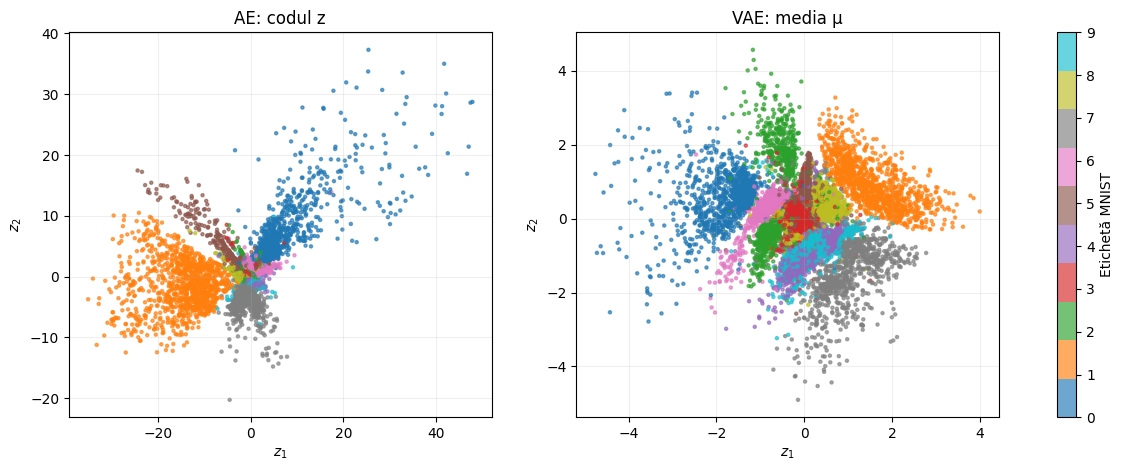

✓ Au fost reprezentate 10000 exemple în spațiul latent 2D.


In [72]:
def collect_latent_codes(model: nn.Module, model_kind: ModelKind, loader: DataLoader) -> tuple[np.ndarray, np.ndarray]:
    """Colectează codurile AE sau mediile μ ale VAE pentru un DataLoader."""
    model.eval()
    codes, all_labels = [], []
    with torch.no_grad():
        for batch_images, batch_labels in loader:
            batch_images = batch_images.to(DEVICE, non_blocking=True)
            if model_kind == "ae":
                code = model.encode(batch_images)
            else:
                code, _ = model.encode(batch_images)
            codes.append(code.cpu())
            all_labels.append(batch_labels)
    return torch.cat(codes).numpy(), torch.cat(all_labels).numpy()


ae_codes, test_labels = collect_latent_codes(ae, "ae", test_loader)
vae_codes, _ = collect_latent_codes(vae, "vae", test_loader)

fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=False, sharey=False)
for axis, codes, title in zip(axes, (ae_codes, vae_codes), ("AE: codul z", "VAE: media μ")):
    scatter = axis.scatter(codes[:, 0], codes[:, 1], c=test_labels, cmap="tab10", s=5, alpha=0.65)
    axis.set(title=title, xlabel="$z_1$", ylabel="$z_2$")
    axis.grid(alpha=0.2)
fig.colorbar(scatter, ax=axes, ticks=range(10), label="Etichetă MNIST")
plt.savefig('figures/latent_space.png')
plt.show()

assert ae_codes.shape[1] == vae_codes.shape[1] == CONFIG.latent_dim == 2
print(f"✓ Au fost reprezentate {len(test_labels)} exemple în spațiul latent 2D.")

### 6.3. Generarea de imagini cu VAE

VAE poate genera cifre noi prin decodarea vectorilor eșantionați din priorul normal standard. Grila regulată evidențiază continuitatea spațiului latent învățat.

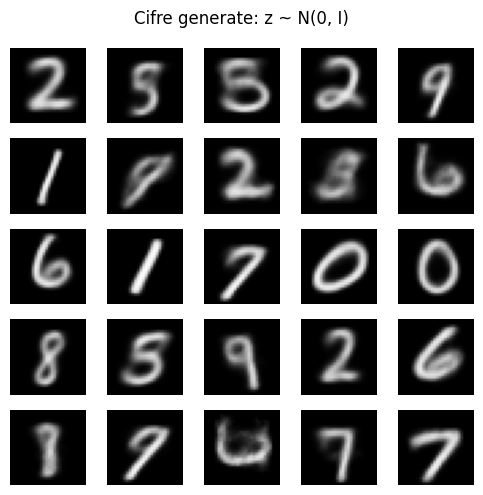

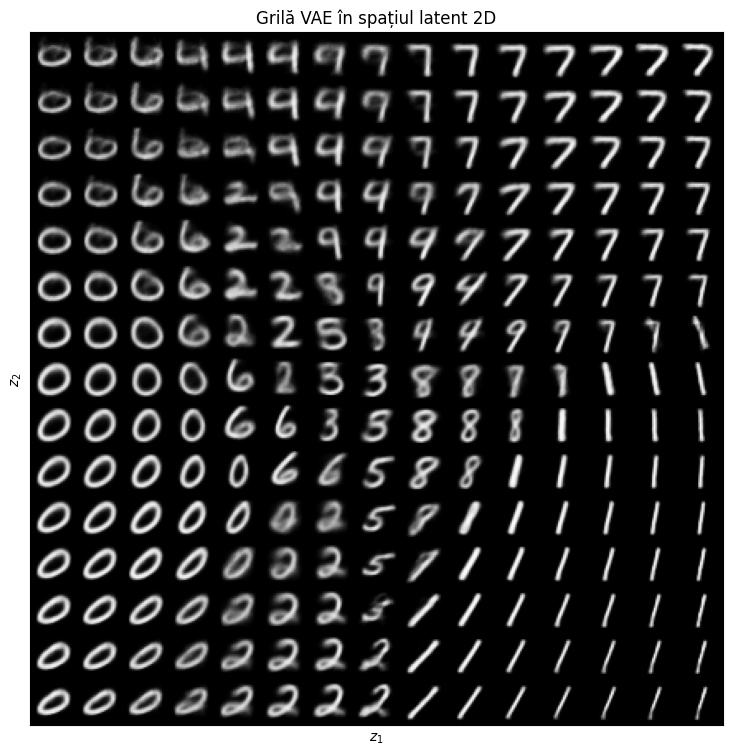

✓ VAE a generat imagini valide din prior și din grila latentă 2D.


In [73]:
def show_image_grid(images: Tensor, rows: int, columns: int, title: str) -> None:
    figure, axes = plt.subplots(rows, columns, figsize=(columns, rows))
    for axis, image in zip(axes.ravel(), images):
        axis.imshow(image.squeeze().cpu(), cmap="gray", vmin=0, vmax=1)
        axis.axis("off")
    figure.suptitle(title)
    plt.tight_layout()
    plt.savefig('figures/execmple_generate.png')
    plt.show()


vae.eval()
with torch.no_grad():
    random_latent = torch.randn(25, CONFIG.latent_dim, device=DEVICE)
    random_samples = vae.decode(random_latent)
show_image_grid(random_samples, rows=5, columns=5, title="Cifre generate: z ~ N(0, I)")

# Grilă regulată în spațiul latent 2D. Valorile ±2 acoperă majoritatea masei priorului normal.
grid_size, latent_limit = 15, 2.5
coordinates = torch.linspace(-latent_limit, latent_limit, grid_size, device=DEVICE)
mesh_x, mesh_y = torch.meshgrid(coordinates, coordinates, indexing="xy")
grid_latent = torch.stack((mesh_x.reshape(-1), mesh_y.reshape(-1)), dim=1)
with torch.no_grad():
    grid_samples = vae.decode(grid_latent)

canvas = torch.zeros(grid_size * 28, grid_size * 28)
for row in range(grid_size):
    for column in range(grid_size):
        image_index = row * grid_size + column
        canvas[row * 28 : (row + 1) * 28, column * 28 : (column + 1) * 28] = grid_samples[image_index, 0].cpu()

plt.figure(figsize=(9, 9))
plt.imshow(canvas, cmap="gray", vmin=0, vmax=1)
plt.title("Grilă VAE în spațiul latent 2D")
plt.xlabel("$z_1$")
plt.ylabel("$z_2$")
plt.xticks([])
plt.yticks([])
plt.savefig('figures/Grilă_VAE.png')
plt.show()

assert random_samples.shape == (25, 1, 28, 28)
assert torch.isfinite(grid_samples).all()
print("✓ VAE a generat imagini valide din prior și din grila latentă 2D.")

## Concluzii

- **AE clasic** optimizează exclusiv fidelitatea reconstrucției și poate produce reconstrucții mai precise pentru același buget de model.
- **VAE** impune o structură probabilistică asupra spațiului latent prin termenul KL. Acest lucru poate mări reconstruction loss, dar permite eșantionarea și generarea coerentă dintr-un prior gaussian.
- Dimensiunea latentă 2 face interpretarea și generarea pe grilă intuitive, însă limitează capacitatea de reprezentare. Se pot investiga ulterior valori mai mari pentru `latent_dim`, valori diferite pentru $\beta$ și arhitecturi convoluționale.
- Pentru raportare, rulați notebook-ul integral cu `FAST_RUN = False`, păstrați graficele și consemnați dispozitivul, timpul de antrenare și metricile finale.